# 03 Churn / Inactivity Labeling

**Project:** AI-Powered Customer Retention Decision Support System for E-Commerce  
**Input tables:** `cleaned_transactions.csv` and `returns_cancellations.csv`  
**Primary output:** `customer_modeling_90d.csv`  
**Label summary:** `churn_label_summary_90d.csv`

This notebook creates the supervised learning target for the retention model. Because the Online Retail II
dataset does not provide a churn label, inactivity is defined from future purchase behavior.

> **Data safety note:** this notebook does **not** overwrite the saved 90-day modeling files unless
> `SAVE_OUTPUTS` is manually changed to `True`.

## Labeling Strategy

The notebook uses a simple historical cutoff design:

1. Use transactions on or before the cutoff date as the information available at prediction time.
2. Use the next 90 days as the future observation window.
3. Label a customer as `inactive_90d = 1` if they do **not** purchase during the future window.
4. Label a customer as `active_90d = 1` if they do purchase during the future window.

This avoids using future information inside the model features while still giving us a measurable target.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 70)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    HAS_PLOTS = True
    sns.set_theme(
        style="whitegrid",
        context="notebook",
        palette="Set2",
        rc={
            "figure.figsize": (11, 5),
            "axes.titleweight": "bold",
            "axes.titlesize": 14,
            "axes.labelsize": 11,
        },
    )
except ImportError:
    HAS_PLOTS = False
    print("Plotting libraries are not available in this environment; chart cells will be skipped.")

In [2]:
# Resolve project paths from the notebook location.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else Path(r"C:/Learning/BANA8083/AI-retention-decision-support")
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLEANED_TRANSACTIONS_PATH = PROCESSED_DIR / "cleaned_transactions.csv"
RETURNS_CANCELLATIONS_PATH = PROCESSED_DIR / "returns_cancellations.csv"
CUSTOMER_MODELING_PATH = PROCESSED_DIR / "customer_modeling_90d.csv"
CHURN_LABEL_SUMMARY_PATH = PROCESSED_DIR / "churn_label_summary_90d.csv"

PREDICTION_WINDOW_DAYS = 90

# Keep this False unless you intentionally want to regenerate the saved 90-day files.
SAVE_OUTPUTS = False

paths = pd.DataFrame(
    {
        "asset": [
            "processed directory",
            "cleaned transactions",
            "returns/cancellations",
            "saved modeling dataset",
            "saved label summary",
        ],
        "path": [
            PROCESSED_DIR,
            CLEANED_TRANSACTIONS_PATH,
            RETURNS_CANCELLATIONS_PATH,
            CUSTOMER_MODELING_PATH,
            CHURN_LABEL_SUMMARY_PATH,
        ],
        "exists": [
            PROCESSED_DIR.exists(),
            CLEANED_TRANSACTIONS_PATH.exists(),
            RETURNS_CANCELLATIONS_PATH.exists(),
            CUSTOMER_MODELING_PATH.exists(),
            CHURN_LABEL_SUMMARY_PATH.exists(),
        ],
    }
)
paths

,asset,path,exists
0,processed directory,c:\Learning\BANA8083\AI-retention-decision-sup...,True
1,cleaned transactions,c:\Learning\BANA8083\AI-retention-decision-sup...,True
2,returns/cancellations,c:\Learning\BANA8083\AI-retention-decision-sup...,True
3,saved modeling dataset,c:\Learning\BANA8083\AI-retention-decision-sup...,True
4,saved label summary,c:\Learning\BANA8083\AI-retention-decision-sup...,True


## 2. Load Cleaned Inputs

In [3]:
cleaned = pd.read_csv(CLEANED_TRANSACTIONS_PATH, parse_dates=["InvoiceDate"])
returns = pd.read_csv(RETURNS_CANCELLATIONS_PATH, parse_dates=["InvoiceDate"])

cleaned["CustomerID"] = cleaned["CustomerID"].astype(int)
returns["CustomerID"] = returns["CustomerID"].astype(int)

print(f"Cleaned transaction rows: {len(cleaned):,}")
print(f"Return/cancellation rows: {len(returns):,}")
print(f"Cleaned date range: {cleaned['InvoiceDate'].min()} to {cleaned['InvoiceDate'].max()}")
print(f"Unique customers in cleaned transactions: {cleaned['CustomerID'].nunique():,}")

cleaned.head()

Cleaned transaction rows: 779,425
Return/cancellation rows: 18,390
Cleaned date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers in cleaned transactions: 5,878


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,IsReturnOrCancel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,13085,United Kingdom,83.4000,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085,United Kingdom,81.0000,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085,United Kingdom,81.0000,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,13085,United Kingdom,100.8000,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,13085,United Kingdom,30.0000,False,False


In [4]:
input_summary = pd.DataFrame(
    {
        "table": ["cleaned_transactions", "returns_cancellations"],
        "rows": [len(cleaned), len(returns)],
        "customers": [cleaned["CustomerID"].nunique(), returns["CustomerID"].nunique()],
        "start_date": [cleaned["InvoiceDate"].min(), returns["InvoiceDate"].min()],
        "end_date": [cleaned["InvoiceDate"].max(), returns["InvoiceDate"].max()],
    }
)
input_summary

,table,rows,customers,start_date,end_date
0,cleaned_transactions,779425,5878,2009-12-01 07:45:00,2011-12-09 12:50:00
1,returns_cancellations,18390,2572,2009-12-01 10:33:00,2011-12-09 11:58:00


## 3. Define Cutoff Date and Future Window

In [5]:
max_date = cleaned["InvoiceDate"].max()
cutoff_date = max_date - pd.Timedelta(days=PREDICTION_WINDOW_DAYS)

history = cleaned[cleaned["InvoiceDate"] <= cutoff_date].copy()
future = cleaned[
    (cleaned["InvoiceDate"] > cutoff_date)
    & (cleaned["InvoiceDate"] <= max_date)
].copy()

window_summary = pd.DataFrame(
    {
        "period": ["history", "future_label_window"],
        "start_date": [history["InvoiceDate"].min(), future["InvoiceDate"].min()],
        "end_date": [history["InvoiceDate"].max(), future["InvoiceDate"].max()],
        "rows": [len(history), len(future)],
        "customers": [history["CustomerID"].nunique(), future["CustomerID"].nunique()],
        "revenue": [history["Revenue"].sum(), future["Revenue"].sum()],
    }
)

print(f"Prediction window: {PREDICTION_WINDOW_DAYS} days")
print(f"Max transaction date: {max_date}")
print(f"Cutoff date: {cutoff_date}")
window_summary

Prediction window: 90 days
Max transaction date: 2011-12-09 12:50:00
Cutoff date: 2011-09-10 12:50:00


,period,start_date,end_date,rows,customers,revenue
0,history,2009-12-01 07:45:00,2011-09-09 15:53:00,620572,5281,"13,930,556.0160"
1,future_label_window,2011-09-11 10:35:00,2011-12-09 12:50:00,158853,2889,"3,444,248.2520"


## 4. Build Historical Customer Features

These features are calculated using only historical transactions on or before the cutoff date. That keeps
the modeling table honest: the model should not learn from purchases that happen inside the label window.

In [6]:
invoice_level = (
    history
    .groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        invoice_date=("InvoiceDate", "max"),
        invoice_revenue=("Revenue", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("StockCode", "nunique"),
    )
)

customer_model = (
    invoice_level
    .groupby("CustomerID")
    .agg(
        first_purchase_date=("invoice_date", "min"),
        last_purchase_date=("invoice_date", "max"),
        frequency=("InvoiceNo", "nunique"),
        monetary_value=("invoice_revenue", "sum"),
        avg_order_value=("invoice_revenue", "mean"),
        total_quantity=("total_quantity", "sum"),
        avg_basket_quantity=("total_quantity", "mean"),
        avg_products_per_order=("unique_products", "mean"),
    )
    .reset_index()
)

customer_model["recency"] = (cutoff_date - customer_model["last_purchase_date"]).dt.days
customer_model["customer_lifetime_days"] = (
    customer_model["last_purchase_date"] - customer_model["first_purchase_date"]
).dt.days

print(f"Historical customer rows: {len(customer_model):,}")
customer_model.head()

Historical customer rows: 5,281


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.4600","6,463.0383",74285,"6,190.4167",2.8333,235,400
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,6,"3,402.3900",567.0650,2099,349.8333,27.3333,39,274
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,4,"1,709.4000",427.3500,2497,624.2500,11.0000,158,189
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.1400",890.3800,993,331.0000,34.0000,317,181
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.4000,334.4000,197,197.0000,17.0000,219,0


## 5. Add Product Breadth and Country Features

In [7]:
def most_common_value(series):
    mode = series.mode(dropna=True)
    return mode.iloc[0] if not mode.empty else np.nan


product_country_features = (
    history
    .groupby("CustomerID")
    .agg(
        product_diversity=("StockCode", "nunique"),
        description_diversity=("Description", "nunique"),
        primary_country=("Country", most_common_value),
    )
    .reset_index()
)

customer_model = customer_model.merge(product_country_features, on="CustomerID", how="left")
customer_model.head()

,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days,product_diversity,description_diversity,primary_country
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.4600","6,463.0383",74285,"6,190.4167",2.8333,235,400,27,26,United Kingdom
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,6,"3,402.3900",567.0650,2099,349.8333,27.3333,39,274,107,107,Iceland
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,4,"1,709.4000",427.3500,2497,624.2500,11.0000,158,189,25,28,Finland
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.1400",890.3800,993,331.0000,34.0000,317,181,90,94,Italy
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.4000,334.4000,197,197.0000,17.0000,219,0,17,17,Norway


## 6. Add Historical Return and Cancellation Features

In [8]:
returns_history = returns[returns["InvoiceDate"] <= cutoff_date].copy()
returns_history["ReturnCancelValue"] = (
    returns_history["Quantity"] * returns_history["UnitPrice"]
).abs()
returns_history["ReturnCancelQuantity"] = returns_history["Quantity"].abs()

return_features = (
    returns_history
    .groupby("CustomerID")
    .agg(
        return_cancel_rows=("InvoiceNo", "size"),
        return_cancel_invoices=("InvoiceNo", "nunique"),
        return_cancel_quantity=("ReturnCancelQuantity", "sum"),
        return_cancel_value=("ReturnCancelValue", "sum"),
    )
    .reset_index()
)

customer_model = customer_model.merge(return_features, on="CustomerID", how="left")

return_columns = [
    "return_cancel_rows",
    "return_cancel_invoices",
    "return_cancel_quantity",
    "return_cancel_value",
]
customer_model[return_columns] = customer_model[return_columns].fillna(0)
customer_model["return_cancel_rate"] = np.where(
    customer_model["frequency"] > 0,
    customer_model["return_cancel_invoices"] / customer_model["frequency"],
    0,
)

print(f"Customers with historical returns/cancellations: {(customer_model['return_cancel_rows'] > 0).sum():,}")
customer_model.head()

Customers with historical returns/cancellations: 2,238


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days,product_diversity,description_diversity,primary_country,return_cancel_rows,return_cancel_invoices,return_cancel_quantity,return_cancel_value,return_cancel_rate
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.4600","6,463.0383",74285,"6,190.4167",2.8333,235,400,27,26,United Kingdom,13.0000,5.0000,"74,232.0000","77,608.2000",0.4167
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,6,"3,402.3900",567.0650,2099,349.8333,27.3333,39,274,107,107,Iceland,0.0000,0.0000,0.0000,0.0000,0.0000
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,4,"1,709.4000",427.3500,2497,624.2500,11.0000,158,189,25,28,Finland,0.0000,0.0000,0.0000,0.0000,0.0000
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.1400",890.3800,993,331.0000,34.0000,317,181,90,94,Italy,5.0000,1.0000,5.0000,24.1500,0.3333
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.4000,334.4000,197,197.0000,17.0000,219,0,17,17,Norway,0.0000,0.0000,0.0000,0.0000,0.0000


## 7. Create 90-Day Activity and Inactivity Labels

In [9]:
future_active_customers = set(future["CustomerID"].unique())

customer_model["active_90d"] = customer_model["CustomerID"].isin(future_active_customers).astype(int)
customer_model["inactive_90d"] = 1 - customer_model["active_90d"]

customer_model = customer_model[
    [
        "CustomerID",
        "first_purchase_date",
        "last_purchase_date",
        "frequency",
        "monetary_value",
        "avg_order_value",
        "total_quantity",
        "avg_basket_quantity",
        "avg_products_per_order",
        "recency",
        "customer_lifetime_days",
        "product_diversity",
        "description_diversity",
        "primary_country",
        "return_cancel_rows",
        "return_cancel_invoices",
        "return_cancel_quantity",
        "return_cancel_value",
        "return_cancel_rate",
        "active_90d",
        "inactive_90d",
    ]
].sort_values("CustomerID").reset_index(drop=True)

print(f"Modeling rows: {len(customer_model):,}")
print(f"Active within 90 days: {customer_model['active_90d'].sum():,}")
print(f"Inactive within 90 days: {customer_model['inactive_90d'].sum():,}")
customer_model.head()

Modeling rows: 5,281
Active within 90 days: 2,292
Inactive within 90 days: 2,989


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days,product_diversity,description_diversity,primary_country,return_cancel_rows,return_cancel_invoices,return_cancel_quantity,return_cancel_value,return_cancel_rate,active_90d,inactive_90d
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.4600","6,463.0383",74285,"6,190.4167",2.8333,235,400,27,26,United Kingdom,13.0000,5.0000,"74,232.0000","77,608.2000",0.4167,0,1
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,6,"3,402.3900",567.0650,2099,349.8333,27.3333,39,274,107,107,Iceland,0.0000,0.0000,0.0000,0.0000,0.0000,1,0
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,4,"1,709.4000",427.3500,2497,624.2500,11.0000,158,189,25,28,Finland,0.0000,0.0000,0.0000,0.0000,0.0000,1,0
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.1400",890.3800,993,331.0000,34.0000,317,181,90,94,Italy,5.0000,1.0000,5.0000,24.1500,0.3333,1,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.4000,334.4000,197,197.0000,17.0000,219,0,17,17,Norway,0.0000,0.0000,0.0000,0.0000,0.0000,0,1


## 8. Review Label Balance

In [10]:
label_summary = (
    customer_model["inactive_90d"]
    .value_counts()
    .rename_axis("inactive_90d")
    .reset_index(name="customer_count")
    .sort_values("inactive_90d", ascending=False)
    .reset_index(drop=True)
)
label_summary["percentage"] = (
    label_summary["customer_count"] / label_summary["customer_count"].sum()
)

label_summary

,inactive_90d,customer_count,percentage
0,1,2989,0.5660
1,0,2292,0.4340


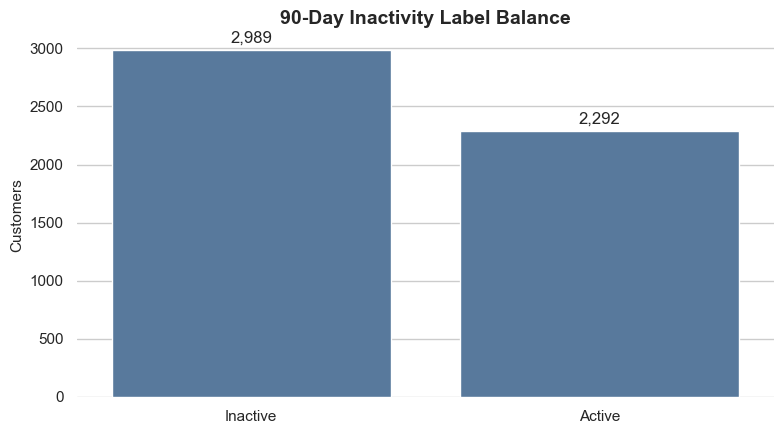

In [11]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_data = label_summary.copy()
    plot_data["label"] = plot_data["inactive_90d"].map({1: "Inactive", 0: "Active"})

    sns.barplot(data=plot_data, x="label", y="customer_count", ax=ax, color="#4C78A8")
    ax.set_title("90-Day Inactivity Label Balance")
    ax.set_xlabel("")
    ax.set_ylabel("Customers")
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

## 9. Feature Checks by Label

In [12]:
label_feature_summary = (
    customer_model
    .groupby("inactive_90d")
    .agg(
        customers=("CustomerID", "count"),
        avg_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        avg_monetary_value=("monetary_value", "mean"),
        median_monetary_value=("monetary_value", "median"),
        avg_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        avg_return_cancel_rate=("return_cancel_rate", "mean"),
    )
    .reset_index()
)

label_feature_summary

,inactive_90d,customers,avg_frequency,median_frequency,avg_monetary_value,median_monetary_value,avg_recency,median_recency,avg_return_cancel_rate
0,0,2292,9.2548,5.0000,"4,598.2427","1,605.4400",120.0432,67.0000,0.2159
1,1,2989,3.0549,2.0000,"1,134.6215",486.8200,274.1793,287.0000,0.1928


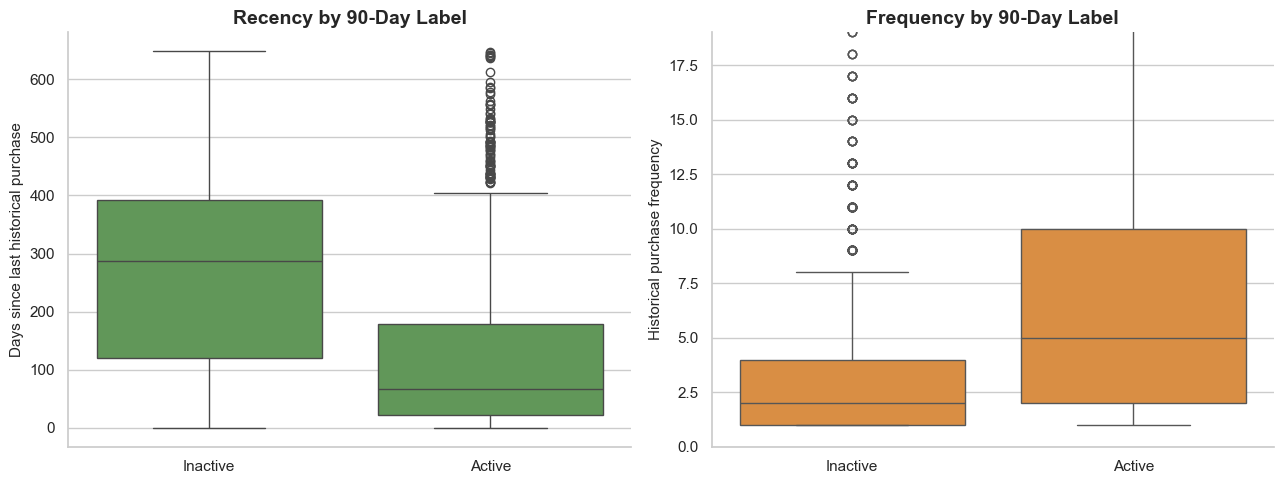

In [13]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plot_data = customer_model.copy()
    plot_data["label"] = plot_data["inactive_90d"].map({1: "Inactive", 0: "Active"})

    sns.boxplot(data=plot_data, x="label", y="recency", ax=axes[0], color="#59A14F")
    axes[0].set_title("Recency by 90-Day Label")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Days since last historical purchase")

    sns.boxplot(data=plot_data, x="label", y="frequency", ax=axes[1], color="#F28E2B")
    axes[1].set_title("Frequency by 90-Day Label")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Historical purchase frequency")
    axes[1].set_ylim(0, customer_model["frequency"].quantile(0.95))

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

## 10. Modeling Table Quality Checks

In [14]:
quality_checks = pd.DataFrame(
    {
        "check": [
            "Modeling rows",
            "Unique CustomerID values",
            "Duplicate CustomerID rows",
            "Missing target labels",
            "Rows with both active_90d and inactive_90d",
            "Rows with neither active_90d nor inactive_90d",
            "Missing primary country",
            "Negative recency rows",
            "Negative monetary value rows",
        ],
        "value": [
            len(customer_model),
            customer_model["CustomerID"].nunique(),
            customer_model["CustomerID"].duplicated().sum(),
            customer_model[["active_90d", "inactive_90d"]].isna().any(axis=1).sum(),
            ((customer_model["active_90d"] == 1) & (customer_model["inactive_90d"] == 1)).sum(),
            ((customer_model["active_90d"] == 0) & (customer_model["inactive_90d"] == 0)).sum(),
            customer_model["primary_country"].isna().sum(),
            (customer_model["recency"] < 0).sum(),
            (customer_model["monetary_value"] < 0).sum(),
        ],
    }
)
quality_checks

,check,value
0,Modeling rows,5281
1,Unique CustomerID values,5281
2,Duplicate CustomerID rows,0
3,Missing target labels,0
4,Rows with both active_90d and inactive_90d,0
5,Rows with neither active_90d nor inactive_90d,0
6,Missing primary country,0
7,Negative recency rows,0
8,Negative monetary value rows,0


## 11. Validate Against Saved 90-Day Files

This section reads the existing saved files and compares them to the regenerated in-memory outputs. It is
a safety check only; it does not write anything.

In [15]:
existing_model = pd.read_csv(
    CUSTOMER_MODELING_PATH,
    parse_dates=["first_purchase_date", "last_purchase_date"],
)
existing_summary = pd.read_csv(CHURN_LABEL_SUMMARY_PATH)

output_validation = pd.DataFrame(
    {
        "check": [
            "model_row_count",
            "model_column_count",
            "unique_customers",
            "inactive_customers",
            "active_customers",
            "label_summary_rows",
        ],
        "existing": [
            len(existing_model),
            existing_model.shape[1],
            existing_model["CustomerID"].nunique(),
            existing_model["inactive_90d"].sum(),
            existing_model["active_90d"].sum(),
            len(existing_summary),
        ],
        "regenerated": [
            len(customer_model),
            customer_model.shape[1],
            customer_model["CustomerID"].nunique(),
            customer_model["inactive_90d"].sum(),
            customer_model["active_90d"].sum(),
            len(label_summary),
        ],
    }
)
output_validation["matches"] = np.isclose(
    output_validation["existing"],
    output_validation["regenerated"],
)
output_validation

,check,existing,regenerated,matches
0,model_row_count,5281,5281,True
1,model_column_count,21,21,True
2,unique_customers,5281,5281,True
3,inactive_customers,2989,2989,True
4,active_customers,2292,2292,True
5,label_summary_rows,2,2,True


In [16]:
summary_compare = existing_summary.merge(
    label_summary,
    on="inactive_90d",
    how="outer",
    suffixes=("_existing", "_regenerated"),
)
summary_compare["customer_count_matches"] = (
    summary_compare["customer_count_existing"] == summary_compare["customer_count_regenerated"]
)
summary_compare["percentage_matches"] = np.isclose(
    summary_compare["percentage_existing"],
    summary_compare["percentage_regenerated"],
)
summary_compare

,inactive_90d,customer_count_existing,percentage_existing,customer_count_regenerated,percentage_regenerated,customer_count_matches,percentage_matches
0,0,2292,0.4340,2292,0.4340,True,True
1,1,2989,0.5660,2989,0.5660,True,True


In [17]:
column_compare = pd.DataFrame(
    {
        "existing_columns": pd.Series(existing_model.columns),
        "regenerated_columns": pd.Series(customer_model.columns),
    }
)
column_compare["matches"] = (
    column_compare["existing_columns"] == column_compare["regenerated_columns"]
)
column_compare

,existing_columns,regenerated_columns,matches
0,CustomerID,CustomerID,True
1,first_purchase_date,first_purchase_date,True
2,last_purchase_date,last_purchase_date,True
3,frequency,frequency,True
4,monetary_value,monetary_value,True
5,avg_order_value,avg_order_value,True
6,total_quantity,total_quantity,True
7,avg_basket_quantity,avg_basket_quantity,True
8,avg_products_per_order,avg_products_per_order,True
9,recency,recency,True


## 12. Optional Export

The saved 90-day modeling files are protected by default. If you intentionally want to overwrite them after
reviewing the regenerated tables and validation checks, change `SAVE_OUTPUTS` to `True` in the setup cell
and rerun this cell.

In [18]:
if SAVE_OUTPUTS:
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    customer_model.to_csv(CUSTOMER_MODELING_PATH, index=False)
    label_summary.to_csv(CHURN_LABEL_SUMMARY_PATH, index=False)
    print(f"Modeling dataset was overwritten because SAVE_OUTPUTS=True: {CUSTOMER_MODELING_PATH}")
    print(f"Label summary was overwritten because SAVE_OUTPUTS=True: {CHURN_LABEL_SUMMARY_PATH}")
else:
    print("SAVE_OUTPUTS=False, so the 90-day modeling files were not written or overwritten.")

SAVE_OUTPUTS=False, so the 90-day modeling files were not written or overwritten.


## 13. Output Readiness

This notebook is complete when:

1. The historical/future split matches the intended 90-day prediction window.
2. The target labels are mutually exclusive and complete.
3. The validation section matches the existing saved 90-day files.
4. `SAVE_OUTPUTS` remains `False` unless an intentional regeneration is needed.

Recommended next notebook: `04_eda_churn_behavior.ipynb`

Next tasks:

1. Compare active vs. inactive customers.
2. Identify churn-risk patterns in recency, frequency, value, product diversity, and returns.
3. Prepare a train/test split for predictive modeling.